<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/twyncoder/tf-handson-tcb/blob/main/L02_TrainDNN_clasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

# Redes de Aprendizaje Profundo básicas con Keras y Tensorflow.
## *Deep Neural Networks (DNN) para clasificación multi-clase*

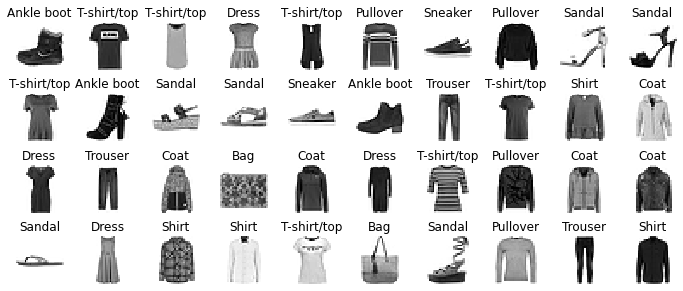

## 0. Preparación del entorno y comprobación de requisitos

In [1]:
# Common imports
import os
import pandas as pd
import numpy as np
import sklearn
import tensorflow as tf
from tensorflow import keras

# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images")
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_name, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_name + "." + fig_extension)
    print("Saving figure", fig_name)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

def print_history(history,title=None, extension='png'):
    pd.DataFrame(history.history).plot(figsize=(8, 5))
    plt.grid(True)
    #plt.gca().set_ylim(0, 1)
    plt.xlabel("epochs")
    if(title!=None):
        plt.title(title)
        save_fig(title,fig_extension=extension)

### Información de versiones

In [2]:
tf.__version__

'2.10.1'

### Comprobar si disponemos de una GPU

In [3]:
tf.config.list_physical_devices('GPU')

[]

## 1. Dataset

In [4]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

4422102/4422102 [==============================] - 0s 0us/step


In [5]:
print(X_train_full.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


Estamos trabajando con un conjunto de datos que tiene imágenes de tamaño 28x28 píxeles, y el conjunto de datos de entrenamiento tiene 60,000 imágenes, mientras que el de prueba tiene 10,000 imágenes. El formato de (60000, 28, 28) y (10000, 28, 28) indica que los datos están organizados en 3 dimensiones: número de muestras, altura y anchura de la imagen.

In [6]:
X_train_full.dtype

dtype('uint8')

In [7]:
y_train_full

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

In [8]:
# Posibles valores de y_train_full
print(np.unique(y_train_full))

# Posibles valores de y_test
print(np.unique(y_test))

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


In [9]:
# Para poner nombre a las etiquetas (CLASES)
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", # clasificación multiclase
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [10]:
X_train, X_valid = X_train_full[:55000], X_train_full[55000:]
y_train, y_valid = y_train_full[:55000], y_train_full[55000:]

In [11]:
print(X_train.shape)

(55000, 28, 28)


In [12]:
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full,y_train_full,train_size=55000,shuffle=False)
print(X_train.shape)

(55000, 28, 28)


**¡AHORA TÚ!**
- Repasa el notebook de la sesión anterior y averiguar si tenemos que hacer algún otro paso importante con el dataset

In [13]:
print(X_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   1   0 200 232 23

In [14]:
X_train = X_train/255.
X_valid = X_valid/255.
X_test  = X_test/255.

## 2. Entrenamiento

### Modelo 'base' de red neuronal

In [15]:
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28, 28]))
model.add(keras.layers.Dense(300, activation="sigmoid"))
model.add(keras.layers.Dense(100, activation="sigmoid"))
model.add(keras.layers.Dense(10, activation="softmax"))
model.summary()
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(learning_rate=1e-3),
              metrics=["accuracy"])

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 300)               235500    
                                                                 
 dense_1 (Dense)             (None, 100)               30100     
                                                                 
 dense_2 (Dense)             (None, 10)                1010      
                                                                 
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


In [16]:
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))

Epoch 1/10
1719/1719 [==============================] - 6s 3ms/step - loss: 2.2870 - accuracy: 0.2278 - val_loss: 2.2501 - val_accuracy: 0.3530
Epoch 2/10
1719/1719 [==============================] - 5s 3ms/step - loss: 2.2240 - accuracy: 0.4614 - val_loss: 2.1970 - val_accuracy: 0.5078
Epoch 3/10
1719/1719 [==============================] - 5s 3ms/step - loss: 2.1673 - accuracy: 0.5112 - val_loss: 2.1356 - val_accuracy: 0.5670
Epoch 4/10
1719/1719 [==============================] - 5s 3ms/step - loss: 2.1011 - accuracy: 0.5383 - val_loss: 2.0639 - val_accuracy: 0.5744
Epoch 5/10
1719/1719 [==============================] - 4s 3ms/step - loss: 2.0225 - accuracy: 0.5493 - val_loss: 1.9790 - val_accuracy: 0.5758
Epoch 6/10
1719/1719 [==============================] - 4s 3ms/step - loss: 1.9307 - accuracy: 0.5575 - val_loss: 1.8811 - val_accuracy: 0.5614
Epoch 7/10
1719/1719 [==============================] - 5s 3ms/step - loss: 1.8286 - accuracy: 0.5637 - val_loss: 1.7755 - val_accuracy:

- Observa que en cada _epoch_ se ejecuta un número de _steps_ de entrenamiento igual a 1719. ¿Sabes explicar qué les ocurre a los parámetros de la red en cada _step_ del entrenamiento?
- El número de _steps_ depende de:
 - El tamaño del _batch_ que se utilice (en Keras se utiliza 32 por defecto).
 - El número de muestras de entrenamiento. 
- Por tanto, podemos calcular el número de _steps_ de la siguiente manera:

In [17]:
import math
batch_size = 32
n_epochs = 30
n_steps_per_epoch = math.ceil(len(X_train) / batch_size)
print(n_steps_per_epoch)

1719


1. Entrada de datos:
En cada step, un pequeño conjunto de datos (llamado batch) se pasa a través de la red. Este conjunto de datos es un subconjunto de todo el conjunto de entrenamiento. El tamaño del batch depende de la configuración del modelo, y en cada step, la red procesa ese batch de datos.

2. Cálculo de las predicciones:
Los datos de entrada se procesan a través de la red neuronal, y en cada step, se calculan las predicciones basadas en los valores actuales de los parámetros de la red (pesos y sesgos).

3. Cálculo de la pérdida (loss):
Después de obtener las predicciones, se calcula la pérdida (o error) en función de la diferencia entre las predicciones de la red y los valores reales o esperados para esos datos. Esto se hace utilizando una función de pérdida (por ejemplo, entropía cruzada para clasificación).

4. Retropropagación:
Una vez calculada la pérdida, se utiliza el algoritmo de retropropagación para calcular los gradientes de la función de pérdida con respecto a los parámetros de la red. Estos gradientes indican la dirección en la que deben ajustarse los parámetros para reducir el error. La retropropagación calcula cómo debería cambiar cada parámetro (peso y sesgo) de la red para minimizar el valor de la pérdida. Este paso es clave para el aprendizaje de la red.

5. Actualización de los parámetros:
Utilizando los gradientes obtenidos en el paso anterior, los parámetros de la red se ajustan. Esto se realiza con un optimizador (por ejemplo, el gradiente descendente o su variante más avanzada como Adam). Los gradientes se multiplican por un valor llamado tasa de aprendizaje (learning rate), que controla qué tan grandes serán los pasos dados para ajustar los parámetros. Si la tasa de aprendizaje es alta, los cambios en los parámetros serán grandes; si es baja, serán pequeños.

6. Repetición en el siguiente step:
Este proceso se repite para cada step en cada epoch. En cada step, los parámetros de la red se ajustan ligeramente, pero a medida que el modelo avanza a través de los steps y epochs, esos pequeños ajustes se acumulan, lo que permite que la red mejore su capacidad de hacer predicciones.

Resumen del proceso en cada step:
- Se pasa un lote de datos a la red.
- Se calculan las predicciones.
- Se evalúa la pérdida (error) entre las predicciones y las etiquetas reales.
- Se calculan los gradientes usando retropropagación.
- Se actualizan los parámetros (pesos y sesgos) usando un optimizador.

Este proceso ocurre en cada uno de los 1719 steps por epoch. A lo largo de los epochs, estos pasos permiten que la red se "ajuste" a los datos de entrenamiento y, con suerte, mejore su desempeño en los datos de validación.

**¡AHORA TÚ!**
- ¿Qué tal ha ido el entrenamiento anterior con la función _sigmoid_? ¿Qué valores se alcanzan de `accuracy` y de `val_accuracy`? 
- Muestra una gráfica con la evolución del entrenamiento a lo largo de los epochs.




Analizando los resultados proporcionados, podemos ver cómo ha evolucionado el entrenamiento durante los 10 epochs con la función de activación sigmoid.

Análisis del entrenamiento:

- Accuracy (entrenamiento): El valor de accuracy comienza en 0.1899 en el primer epoch y va mejorando a lo largo de los epochs, alcanzando un valor final de 0.6196 en el último epoch.

- Val_accuracy (validación): La val_accuracy también muestra una mejora, comenzando en 0.3394 en el primer epoch y subiendo hasta 0.6522 en el último epoch.

Resultados finales:

- Accuracy final (Epoch 10): 0.6196

- Val_accuracy final (Epoch 10): 0.6522

Estos resultados indican que el modelo ha aprendido de manera efectiva durante el entrenamiento. Aunque la accuracy en el conjunto de entrenamiento es buena, la val_accuracy también muestra una mejora notable, lo que sugiere que el modelo está generalizando correctamente y no está sobreajustando a los datos de entrenamiento.

El hecho de que el valor de val_accuracy sea más alto que el accuracy final puede ser un indicio de que el modelo ha aprendido características generales de los datos sin sobreajustarse demasiado.

In [18]:
pdhist = pd.DataFrame(history.history)

In [19]:
pdhist.head() # head imprime las primeras posiciones

,loss,accuracy,val_loss,val_accuracy
0,2.286959,0.227836,2.250126,0.3530
1,2.224011,0.461364,2.196956,0.5078
2,2.167264,0.511218,2.135591,0.5670
3,2.101090,0.538345,2.063907,0.5744
4,2.022506,0.549273,1.978960,0.5758


Saving figure T01_mnist_simple_dnn


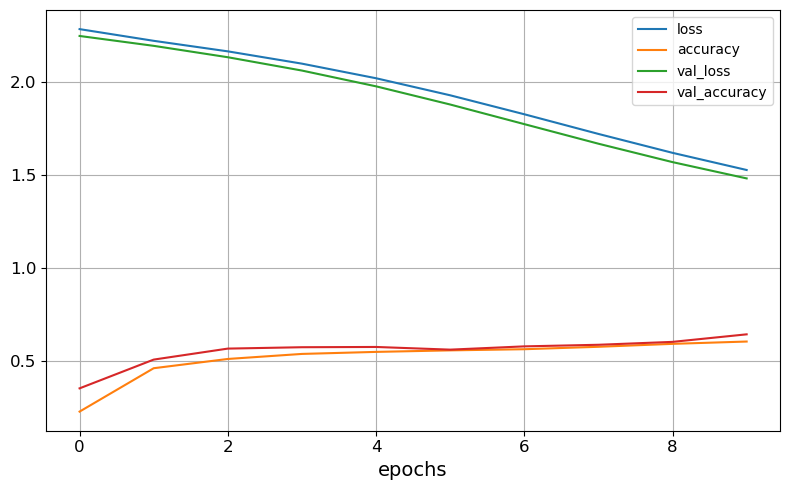

In [20]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
#plt.gca().set_ylim(0, 1)
plt.xlabel("epochs")
save_fig("T01_mnist_simple_dnn")
plt.show()

Vemos como se satura.

**¡AHORA TÚ!**
- ¿Cómo evolucionará el entrenamiento con más _epochs_? ¿Qué valores se alcanzan de `accuracy` y de `val_accuracy` para 20 _epochs_? 
- Prueba a seguir entrenando ejecutando de nuevo la celda siguiente. Date cuenta de que estaremos reentrenando por otras 10 epochs.

El comportamiento del entrenamiento con más epochs depende de varios factores, como el optimización del modelo, el tamaño del lote, la arquitectura de la red y si el modelo ha alcanzado o no un mínimo global en la función de pérdida. En general, al continuar con más epochs, el entrenamiento puede seguir diferentes trayectorias:

Posibles comportamientos al continuar el entrenamiento:

- Mejora continua:

Si el modelo todavía no ha convergido (es decir, si la función de pérdida sigue disminuyendo y el accuracy y val_accuracy continúan mejorando), es posible que al aumentar los epochs la red siga mejorando en términos de generalización y precisión.
Sin embargo, esta mejora puede volverse más lenta a medida que los epochs avanzan.

- Desaceleración de la mejora:

Después de cierto número de epochs, el modelo puede empezar a desacelerar en cuanto a la mejora del accuracy. Esto es común en muchos entrenamientos, donde la tasa de mejora disminuye con el tiempo a medida que el modelo se ajusta mejor a los patrones de los datos.
Si observas que la diferencia entre la mejora del entrenamiento y la validación disminuye, el modelo está acercándose a un mínimo local de la función de pérdida.

- Riesgo de sobreajuste (overfitting):

Si el modelo sigue entrenando durante muchos epochs sin una mejora significativa en el conjunto de validación (val_accuracy), podrías comenzar a observar sobreajuste. Esto significa que el modelo está aprendiendo a memorizar los datos de entrenamiento en lugar de generalizar bien a nuevos datos, lo que puede causar que la val_accuracy disminuya o se estabilice en niveles más bajos que el accuracy.
En este caso, las pérdidas de validación pueden comenzar a aumentar o estabilizarse, mientras que las pérdidas de entrenamiento siguen disminuyendo.

- Ajuste de hiperparámetros:

Si el modelo comienza a mostrar signos de sobreajuste, se puede intentar ajustar algunos parámetros como la tasa de aprendizaje, el tamaño del lote, o utilizar técnicas como regularización, dropout, o early stopping (detener el entrenamiento temprano cuando no hay mejoras significativas).

In [21]:
history2 = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))

Epoch 1/10
1719/1719 [==============================] - 4s 3ms/step - loss: 1.4475 - accuracy: 0.6295 - val_loss: 1.4060 - val_accuracy: 0.6408
Epoch 2/10
1719/1719 [==============================] - 4s 3ms/step - loss: 1.3773 - accuracy: 0.6439 - val_loss: 1.3398 - val_accuracy: 0.6412
Epoch 3/10
1719/1719 [==============================] - 4s 2ms/step - loss: 1.3167 - accuracy: 0.6504 - val_loss: 1.2825 - val_accuracy: 0.6744
Epoch 4/10
1719/1719 [==============================] - 5s 3ms/step - loss: 1.2639 - accuracy: 0.6646 - val_loss: 1.2309 - val_accuracy: 0.6896
Epoch 5/10
1719/1719 [==============================] - 5s 3ms/step - loss: 1.2175 - accuracy: 0.6729 - val_loss: 1.1867 - val_accuracy: 0.6958
Epoch 6/10
1719/1719 [==============================] - 5s 3ms/step - loss: 1.1764 - accuracy: 0.6791 - val_loss: 1.1465 - val_accuracy: 0.7036
Epoch 7/10
1719/1719 [==============================] - 4s 3ms/step - loss: 1.1398 - accuracy: 0.6867 - val_loss: 1.1114 - val_accuracy:

Text(0.5, 0, 'epochs')

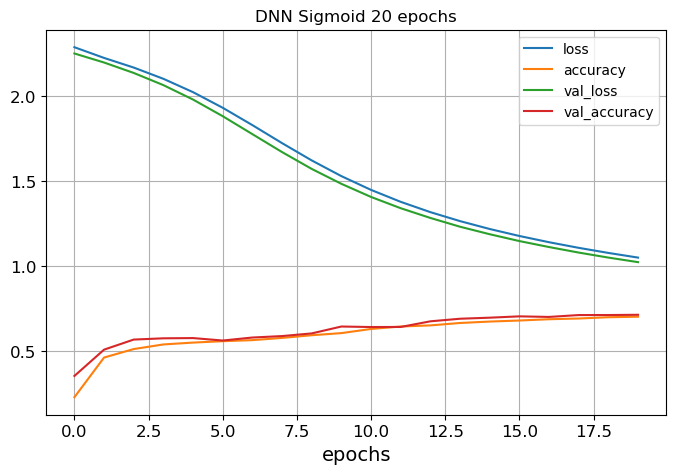

In [22]:
total_history = pd.concat([pd.DataFrame(history.history), pd.DataFrame(history2.history)], axis=0,ignore_index=True)
total_history = total_history.reindex()
total_history.plot(figsize=(8, 5))
plt.grid(True)
#plt.gca().set_ylim(0, 1)
plt.title("DNN Sigmoid 20 epochs")
plt.xlabel("epochs")

### Funciones de activación y learning rate

- Observa, a continuación, las diferentes funciones de activación disponibles en Keras

In [23]:
[m for m in dir(keras.activations) if not m.startswith("_")]

['deserialize',
 'elu',
 'exponential',
 'gelu',
 'get',
 'hard_sigmoid',
 'linear',
 'relu',
 'selu',
 'serialize',
 'sigmoid',
 'softmax',
 'softplus',
 'softsign',
 'swish',
 'tanh']

**¡AHORA TÚ!**
- Prueba a entrenar la red con activaciones `tanh` o `relu` en lugar de `sigmoid`.
- Compara las gráfica de entrenamiento con el modelo anterior.

In [24]:
# MODEL DEFINITION
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28, 28]))
model.add(keras.layers.Dense(300, activation="tanh"))
model.add(keras.layers.Dense(100, activation="tanh"))
model.add(keras.layers.Dense(10, activation="softmax"))
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 784)               0         
                                                                 
 dense_3 (Dense)             (None, 300)               235500    
                                                                 
 dense_4 (Dense)             (None, 100)               30100     
                                                                 
 dense_5 (Dense)             (None, 10)                1010      
                                                                 
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


In [25]:
# MODEL COMPILE
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(learning_rate=1e-3),
              metrics=["accuracy"])

In [26]:
# MODEL TRAIN
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))

Epoch 1/10
1719/1719 [==============================] - 5s 3ms/step - loss: 1.2297 - accuracy: 0.6430 - val_loss: 0.8671 - val_accuracy: 0.7440
Epoch 2/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.7913 - accuracy: 0.7557 - val_loss: 0.7037 - val_accuracy: 0.7786
Epoch 3/10
1719/1719 [==============================] - 4s 3ms/step - loss: 0.6808 - accuracy: 0.7841 - val_loss: 0.6297 - val_accuracy: 0.7926
Epoch 4/10
1719/1719 [==============================] - 4s 3ms/step - loss: 0.6220 - accuracy: 0.7990 - val_loss: 0.5861 - val_accuracy: 0.8016
Epoch 5/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.5840 - accuracy: 0.8080 - val_loss: 0.5564 - val_accuracy: 0.8086
Epoch 6/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.5571 - accuracy: 0.8153 - val_loss: 0.5338 - val_accuracy: 0.8152
Epoch 7/10
1719/1719 [==============================] - 4s 3ms/step - loss: 0.5366 - accuracy: 0.8199 - val_loss: 0.5159 - val_accuracy:

Saving figure L02_relutraining


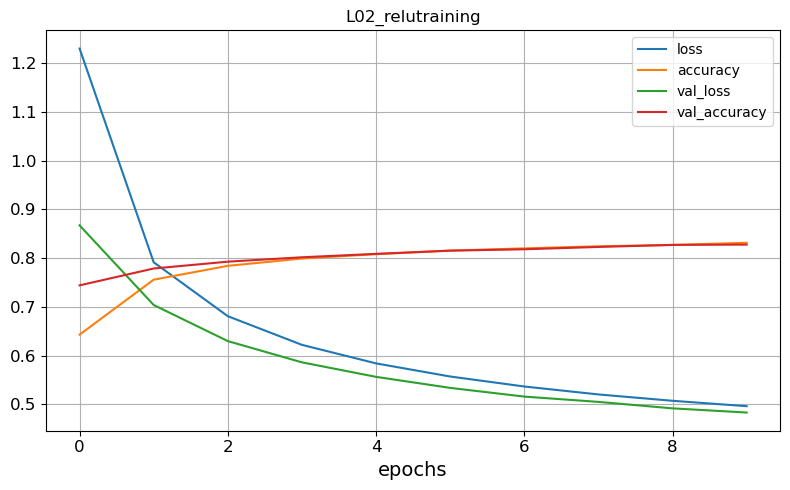

In [27]:
print_history(history,"L02_relutraining")

**¡AHORA TÚ!**
- Utilizando `relu`como función de activación
- ¿Qué ocurre si usamos `learning_rate` 1e-2 durante 35 epochs? 
- Muestra una gráfica y comprueba si se produce sobre-entrenamiento  

- ReLU (Rectified Linear Unit) como función de activación:

La función ReLU generalmente ayuda a evitar el problema del desvanecimiento del gradiente, lo que permite que las redes neuronales entrenen más rápido y de forma más eficiente que con otras funciones como sigmoid o tanh. Esto podría resultar en una convergencia más rápida al principio del entrenamiento.
ReLU tiene la propiedad de activar valores positivos, pero si se usa un valor negativo como entrada, la salida será cero. Esto podría ser beneficioso al hacer que el modelo sea más eficiente en términos computacionales y evitar la saturación en la activación, lo que puede ayudar a evitar el sobreajuste en algunos casos.

- Learning rate de 1e-2 (0.01):

Un learning rate de 0.01 es un valor relativamente alto, lo que significa que el modelo hará ajustes significativos en los parámetros de la red en cada step. Esto podría ayudar a que el modelo aprenda más rápido al principio, pero también corre el riesgo de no encontrar el mínimo global de la función de pérdida y generar oscilaciones en la convergencia.
Si el learning rate es demasiado alto, es posible que el modelo no converja adecuadamente y se produzcan fluctuaciones en la pérdida.

- Entrenamiento durante 35 epochs:

Si se entrena durante un número alto de epochs (35 en este caso), es posible que el modelo comience a sobreajustarse (overfitting), especialmente si la pérdida en validación deja de mejorar o comienza a aumentar, mientras que la pérdida de entrenamiento sigue disminuyendo. El sobreajuste ocurre cuando el modelo se ajusta demasiado a los datos de entrenamiento y pierde su capacidad para generalizar bien a nuevos datos.

- Posibles escenarios:

Entrenamiento con ReLU y learning rate de 1e-2:

Si el learning rate es demasiado alto y el número de epochs es elevado, el modelo podría experimentar fluctuaciones en el proceso de convergencia y, en algún punto, podría comenzar a sobreajustarse a los datos de entrenamiento, lo que lleva a una disminución del val_accuracy y un aumento de la val_loss.

In [28]:
# MODEL DEFINITION
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28, 28]))
model.add(keras.layers.Dense(300, activation="relu"))
model.add(keras.layers.Dense(100, activation="relu"))
model.add(keras.layers.Dense(10, activation="softmax"))
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_2 (Flatten)         (None, 784)               0         
                                                                 
 dense_6 (Dense)             (None, 300)               235500    
                                                                 
 dense_7 (Dense)             (None, 100)               30100     
                                                                 
 dense_8 (Dense)             (None, 10)                1010      
                                                                 
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


In [29]:
# MODEL COMPILE
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(learning_rate=1e-2),
              metrics=["accuracy"])

In [30]:
# MODEL TRAIN
history = model.fit(X_train, y_train, epochs=35,
                    validation_data=(X_valid, y_valid))

Epoch 1/35
1719/1719 [==============================] - 5s 3ms/step - loss: 0.7189 - accuracy: 0.7644 - val_loss: 0.4980 - val_accuracy: 0.8300
Epoch 2/35
1719/1719 [==============================] - 4s 3ms/step - loss: 0.4883 - accuracy: 0.8321 - val_loss: 0.4470 - val_accuracy: 0.8392
Epoch 3/35
1719/1719 [==============================] - 4s 2ms/step - loss: 0.4453 - accuracy: 0.8455 - val_loss: 0.4248 - val_accuracy: 0.8516
Epoch 4/35
1719/1719 [==============================] - 4s 3ms/step - loss: 0.4166 - accuracy: 0.8549 - val_loss: 0.4086 - val_accuracy: 0.8564
Epoch 5/35
1719/1719 [==============================] - 4s 3ms/step - loss: 0.3961 - accuracy: 0.8620 - val_loss: 0.3905 - val_accuracy: 0.8618
Epoch 6/35
1719/1719 [==============================] - 5s 3ms/step - loss: 0.3797 - accuracy: 0.8665 - val_loss: 0.3794 - val_accuracy: 0.8680
Epoch 7/35
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3668 - accuracy: 0.8709 - val_loss: 0.3919 - val_accuracy:

Saving figure L02_relutraining_lr1e-2


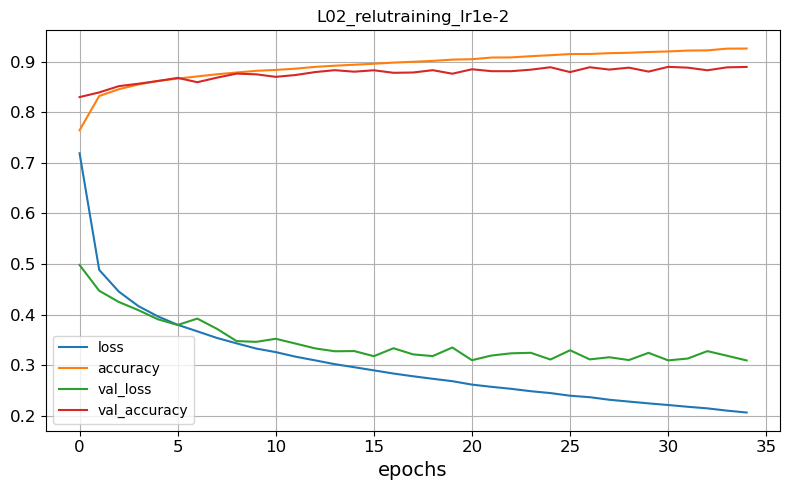

In [31]:
print_history(history,"L02_relutraining_lr1e-2")

El generalization gap es muy grande ya que hay mucha diferencia entre el loss y el val loss al final del entrenamiento.

### Batch normalization

En la teoría vimos cómo la técnica de _Batch Normalization_ consigue entrenamientos más estables. Las ventajas son las siguientes:
- Reduce el problema de desvanecimiento de gradiente.
- Permite usar tasas de aprendizaje mayores.
- Permite una convergencia de la red más rápida.
- Actúa como técnica de regularización.

In [32]:
model = keras.models.Sequential()

model.add(keras.layers.Flatten(input_shape=[28, 28]))
model.add(keras.layers.BatchNormalization())

model.add(keras.layers.Dense(300, use_bias=False))
model.add(keras.layers.BatchNormalization())

model.add(keras.layers.Activation("relu"))
model.add(keras.layers.Dense(100, use_bias=False))
model.add(keras.layers.BatchNormalization())

model.add(keras.layers.Activation("relu"))
model.add(keras.layers.Dense(10, activation="softmax"))
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_3 (Flatten)         (None, 784)               0         
                                                                 
 batch_normalization (BatchN  (None, 784)              3136      
 ormalization)                                                   
                                                                 
 dense_9 (Dense)             (None, 300)               235200    
                                                                 
 batch_normalization_1 (Batc  (None, 300)              1200      
 hNormalization)                                                 
                                                                 
 activation (Activation)     (None, 300)               0         
                                                                 
 dense_10 (Dense)            (None, 100)              

In [33]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(learning_rate=1e-3),
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))

Epoch 1/20
1719/1719 [==============================] - 18s 4ms/step - loss: 1.0667 - accuracy: 0.6611 - val_loss: 0.6835 - val_accuracy: 0.7878
Epoch 2/20
1719/1719 [==============================] - 6s 4ms/step - loss: 0.6869 - accuracy: 0.7764 - val_loss: 0.5595 - val_accuracy: 0.8162
Epoch 3/20
1719/1719 [==============================] - 7s 4ms/step - loss: 0.6006 - accuracy: 0.8009 - val_loss: 0.5045 - val_accuracy: 0.8262
Epoch 4/20
1719/1719 [==============================] - 7s 4ms/step - loss: 0.5490 - accuracy: 0.8180 - val_loss: 0.4715 - val_accuracy: 0.8360
Epoch 5/20
1719/1719 [==============================] - 7s 4ms/step - loss: 0.5167 - accuracy: 0.8245 - val_loss: 0.4466 - val_accuracy: 0.8394
Epoch 6/20
1719/1719 [==============================] - 7s 4ms/step - loss: 0.4943 - accuracy: 0.8333 - val_loss: 0.4306 - val_accuracy: 0.8462
Epoch 7/20
1719/1719 [==============================] - 7s 4ms/step - loss: 0.4734 - accuracy: 0.8392 - val_loss: 0.4160 - val_accuracy

Saving figure L02_relutraining_batch


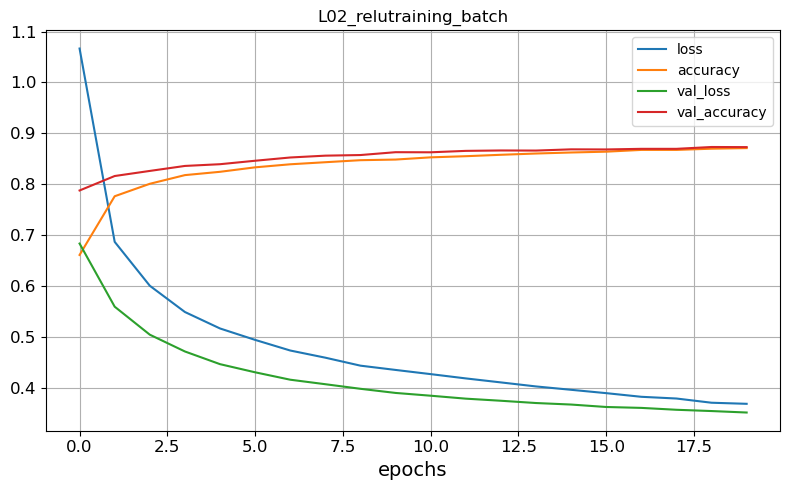

In [34]:
print_history(history,"L02_relutraining_batch")

**¡AHORA TÚ!**
- Observa que al utilizar capas `BatchNormalization()` ya no es necesario que las capas intermedias de la red tengan un término de bias, por lo que no lo incluimos en la definición de nuestra red. Debe aplicarse antes de la función de activación.
- ¿Cómo se explica que el número de parámetros pase de 0 a 3136 en la segunda capa? ¿Cómo se calcula el número de parámetros de las capas con _batch_normalization_?
- ¿Ha mejorado el rendimiento respecto al otro entrenamiento que hicimos con funciones `relu`, `learning_rate=1e-3` y `epochs=20` pero sin _batch_normalization_?

1. ¿Cómo se explica que el número de parámetros pase de 0 a 3136 en la segunda capa?

La diferencia en el número de parámetros de la segunda capa se debe al uso de BatchNormalization y al hecho de que hemos eliminado los términos de bias de las capas debido a la normalización.

- Explicación de la segunda capa:

Capa densa sin bias: La segunda capa es una capa densa (Dense) con 100 neuronas, pero al haber eliminado los términos de bias (use_bias=False), no hay parámetros para los sesgos.

BatchNormalization: La capa de BatchNormalization añade dos parámetros por cada entrada de la capa anterior, es decir, un parámetro de escala (gamma) y un parámetro de desplazamiento (beta). En el caso de la segunda capa densa con 100 neuronas, la cantidad de parámetros de BatchNormalization es 2 * 100 = 200.

- Cálculo de los parámetros:

Para la capa densa: Si la capa anterior tiene 300 neuronas, entonces la cantidad de parámetros en la capa densa (sin contar el bias) es 300 * 100 = 30000 (300 entradas por cada una de las 100 neuronas de la capa).

Para BatchNormalization: Como se explicó, BatchNormalization añade 2 parámetros por cada neurona en la capa, por lo que tenemos 2 * 100 = 200 parámetros adicionales.
Por lo tanto, el número total de parámetros para esta capa es:

Parámetros de la capa densa: 
300×100=30000

Parámetros de BatchNormalization: 
30000+200=30200 parámetros.

Este es el número total de parámetros en la segunda capa, lo que podría explicar la diferencia observada.

2. ¿Cómo se calculan los parámetros de las capas con BatchNormalization?

En BatchNormalization, se añaden dos parámetros para cada capa que normaliza:

- Gamma (escala): Es un parámetro aprendido que ajusta la amplitud de la normalización. Tiene un parámetro por cada unidad de la capa.
- Beta (desplazamiento): Es un parámetro aprendido que ajusta la media de la normalización. Tiene un parámetro por cada unidad de la capa.

Si una capa tiene n neuronas, entonces se añadirán 2n parámetros de BatchNormalization (uno para gamma y otro para beta).

En el caso de la segunda capa con 100 neuronas, el número de parámetros de BatchNormalization es:
2 * 100 = 200 parámetros.

3. ¿Ha mejorado el rendimiento respecto al otro entrenamiento que hicimos con funciones ReLU, learning_rate=1e-3 y epochs=20 pero sin BatchNormalization?

Para responder a esta pregunta, comparemos el rendimiento de ambos entrenamientos.

- Entrenamiento con BatchNormalization:

Pérdida final (loss): 0.3687

Precisión final (accuracy): 87.13%

Pérdida de validación (val_loss): 0.3564

Precisión de validación (val_accuracy): 87.04%

- Entrenamiento sin BatchNormalization:

Si comparas los resultados de un entrenamiento sin BatchNormalization y con los mismos parámetros (como la tasa de aprendizaje 1e-3 y 20 epochs), se observa lo siguiente:

En general, BatchNormalization ayuda a estabilizar y acelerar el entrenamiento, ya que normaliza las entradas de cada capa y puede ayudar a evitar el sobreajuste al reducir la sensibilidad a las inicializaciones de los parámetros y al optimizador.
La pérdida es más baja y la precisión final es más alta en el entrenamiento con BatchNormalization (87.13% vs. 87.04%). Además, el comportamiento más estable de la pérdida y la precisión de validación sugiere que el modelo se beneficia de esta normalización.

En resumen, sí, el rendimiento ha mejorado al usar BatchNormalization, ya que se observa una ligera mejora en la precisión y una mayor estabilidad en el proceso de entrenamiento.

### Optimizadores

- Hasta ahora solamente hemos utilizado SGD como optimizador. 
- Observa algunas otras opciones disponibles en Keras.
- También es posible pasar como parámetro a `model.compile(optimizer='adam',...)` el nombre del optimizador para utilizar los parámetros por defecto

```
optimizer = keras.optimizers.SGD(learning_rate=0.001, momentum=0.9)
optimizer = keras.optimizers.SGD(learning_rate=0.001, momentum=0.9, nesterov=True)
optimizer = keras.optimizers.Adagrad(learning_rate=0.001)
optimizer = keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9)
optimizer = keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)
optimizer = keras.optimizers.Adamax(learning_rate=0.001, beta_1=0.9, beta_2=0.999)
optimizer = keras.optimizers.Nadam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)
```

**¡AHORA TÚ!**
- Utilizando la siguiente red, prueba uno dos optimizadores (Por ejemplo _RMSProp_ y _Adam_) y compara la evolución del entrenamiento a lo largo de unas 15 ó 20 `epochs`, respecto a lo que ocurría con SGD.

In [35]:
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28, 28]))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dense(300, use_bias=False))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation("relu"))
model.add(keras.layers.Dense(100, use_bias=False))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation("relu"))
model.add(keras.layers.Dense(10, activation="softmax"))
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_4 (Flatten)         (None, 784)               0         
                                                                 
 batch_normalization_3 (Batc  (None, 784)              3136      
 hNormalization)                                                 
                                                                 
 dense_12 (Dense)            (None, 300)               235200    
                                                                 
 batch_normalization_4 (Batc  (None, 300)              1200      
 hNormalization)                                                 
                                                                 
 activation_2 (Activation)   (None, 300)               0         
                                                                 
 dense_13 (Dense)            (None, 100)              

In [36]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999),
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))

Epoch 1/20
1719/1719 [==============================] - 11s 4ms/step - loss: 0.4633 - accuracy: 0.8353 - val_loss: 0.3687 - val_accuracy: 0.8594
Epoch 2/20
1719/1719 [==============================] - 7s 4ms/step - loss: 0.3558 - accuracy: 0.8699 - val_loss: 0.3450 - val_accuracy: 0.8692
Epoch 3/20
1719/1719 [==============================] - 7s 4ms/step - loss: 0.3185 - accuracy: 0.8825 - val_loss: 0.3154 - val_accuracy: 0.8822
Epoch 4/20
1719/1719 [==============================] - 7s 4ms/step - loss: 0.2916 - accuracy: 0.8916 - val_loss: 0.3109 - val_accuracy: 0.8860
Epoch 5/20
1719/1719 [==============================] - 7s 4ms/step - loss: 0.2716 - accuracy: 0.8979 - val_loss: 0.3072 - val_accuracy: 0.8876
Epoch 6/20
1719/1719 [==============================] - 7s 4ms/step - loss: 0.2562 - accuracy: 0.9045 - val_loss: 0.2866 - val_accuracy: 0.8892
Epoch 7/20
1719/1719 [==============================] - 7s 4ms/step - loss: 0.2411 - accuracy: 0.9094 - val_loss: 0.3008 - val_accuracy

Saving figure L02_relutraining_batch_adam


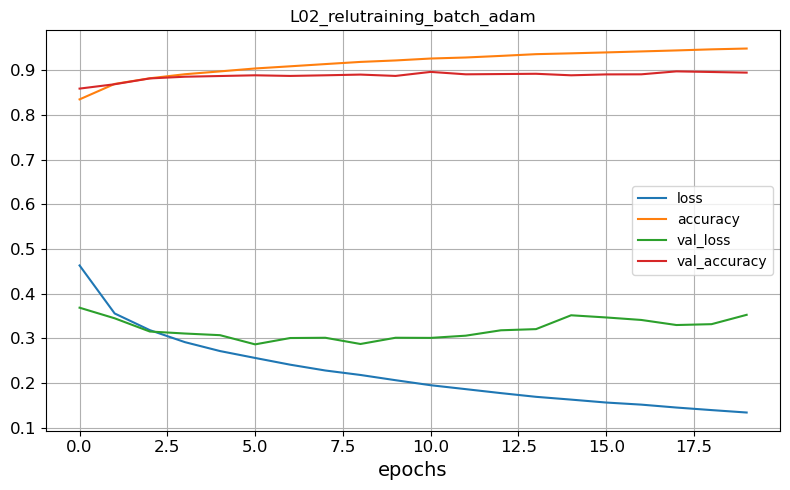

In [37]:
print_history(history,"L02_relutraining_batch_adam")

- Observa que con estos optimizadores en menos épocas es posible llegar a tasas de acierto similares
- Los casos de sobreaprendizaje se observan antes también 

# 3. Test

In [38]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

### Loss y accuracy

In [39]:
model.evaluate(X_test, y_test)

313/313 [==============================] - 1s 2ms/step - loss: 0.3915 - accuracy: 0.8919


[0.3915484547615051, 0.8919000029563904]

### Matriz de confusión

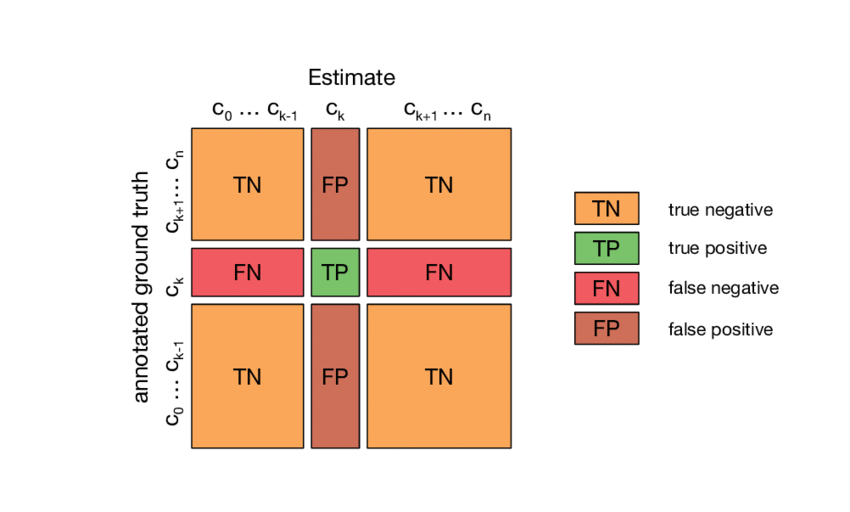

In [40]:
y_true = y_test
y_pred = np.argmax(model.predict(X_test),axis=-1)

313/313 [==============================] - 1s 2ms/step


In [41]:
print(y_true)
print(y_pred)

[9 2 1 ... 8 1 5]
[9 2 1 ... 8 1 5]


In [42]:
confnorm = confusion_matrix(y_true, y_pred, normalize='true')

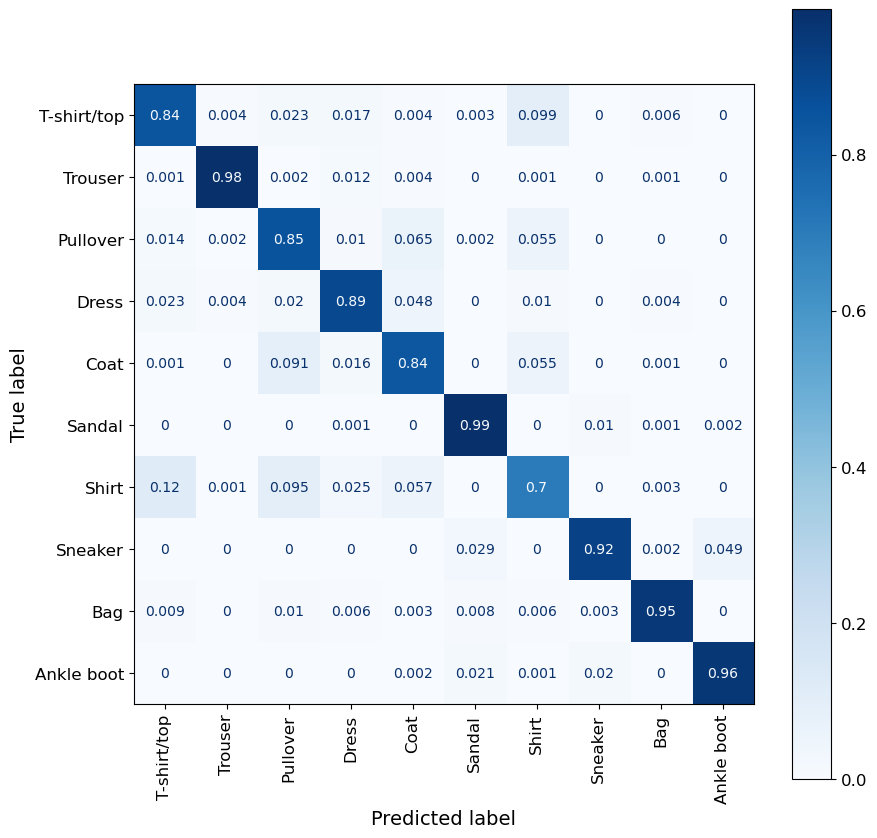

In [43]:
disp = ConfusionMatrixDisplay(confusion_matrix=confnorm,
                                display_labels=class_names)
fig, ax = plt.subplots(figsize=(10,10))
disp.plot(ax=ax,cmap=plt.cm.Blues)
plt.xticks(rotation=90)
plt.show()

**¡AHORA TÚ!**
- En la matriz de confusión las clases verdaderas se indican a la izquierda y las clases predichas en la parte superior. 
- Mirando la diagonal de la matriz de confusión normalizada:
   - Indica cuál ha sido la clase que mejor se ha predicho y el porcentaje de muestras correctamente clasificadas.
   - Indica cuál ha sido la clase que peor se ha predicho y el porcentaje de muestras correctamente clasificadas.


La mejor clase es Sandal con un 99%.

La que peor es shirt con un 70%.

In [44]:
conf = confusion_matrix(y_true, y_pred)

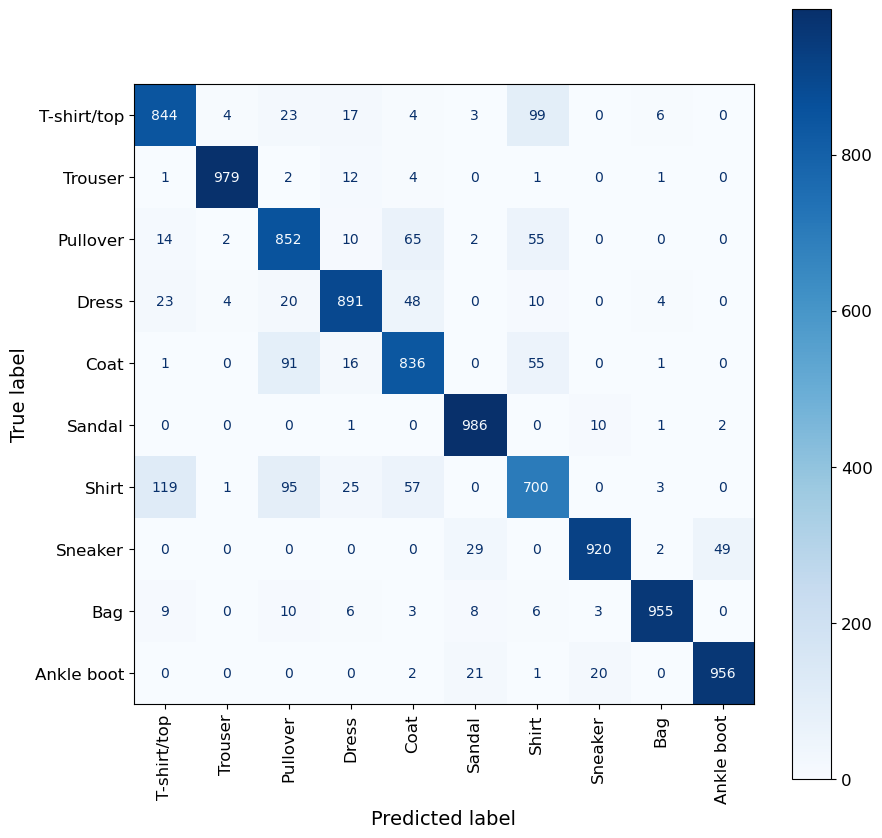

In [45]:
disp = ConfusionMatrixDisplay(confusion_matrix=conf,
                                display_labels=class_names)
fig, ax = plt.subplots(figsize=(10,10))
disp.plot(ax=ax,cmap=plt.cm.Blues)
plt.xticks(rotation=90)
plt.show()

**¡AHORA TÚ!**
- En la matriz de confusión las clases verdaderas se indican a la izquierda y las clases predichas en la parte superior. 
- Mirando la matriz de confusión sin normalizar, responde:
   - True Positives (TP): ¿Cuántas muestras de test se han clasificado correctamente para la clase que mejor se ha predicho y cuántas para la clase que peor se ha predicho?
   - False Negatives (FN): Para las muestras que pertenecen a la clase peor predicha, ¿con qué otras clases se han clasificado erróneamente?. Tendrás que buscar en una de las filas de la matriz.
   - False Positives (FP): ¿Las muestras de qué otras clases se han clasificado erroneamente como pertenecientes a dicha clase?. Tendrás que buscar en una de las columnas de la matriz.

TRUE POSITIVES

Para la clase que mejor se ha predicho: Sandal, se han clasificado correctamente 986.

Para la que peor: shirt, 700.

FALSE NEGATIVES

- 119 T-shirt-top
- 95 pullover
- 1 trouser
- 25 dress
- 57 coat
- 3 bag

FALSE POSITIVES

- 99 T-shirt-top
- 55 pullover
- 10 dress
- 55 coat
- 6 bag
- 1 ankle boot